EXPERIMENT 12
Actor-Critic Reinforcement Learning using A2C and A3C

Training A2C...
A2C Completed

Training A3C...
A3C Completed


SAMPLE DATASET


,Episode,A2C_Reward,A3C_Reward,A2C_Actor_Loss,A3C_Actor_Loss,A2C_Critic_Loss,A3C_Critic_Loss,A2C_Episode_Length,A3C_Episode_Length
0,1,76.0,19.0,21.209435,6.544782,1156.756104,113.541954,76,19
1,2,18.0,14.0,6.178280,5.139044,102.103600,66.009743,18,14
2,3,28.0,17.0,9.218443,5.970350,223.851837,93.648888,28,17
3,4,15.0,64.0,5.197430,18.365911,72.281006,897.326050,15,64
4,5,52.0,30.0,15.655766,9.692276,638.860901,253.186630,52,30
5,6,31.0,20.0,9.968352,6.962382,265.680603,124.751122,31,20
6,7,25.0,26.0,8.193936,8.709496,181.270630,199.516083,25,26
7,8,21.0,24.0,6.970363,8.092650,132.180679,173.369644,21,24
8,9,13.0,22.0,4.323061,7.356348,54.734116,146.502518,13,22
9,10,21.0,19.0,6.996912,6.474932,132.181061,113.002968,21,19


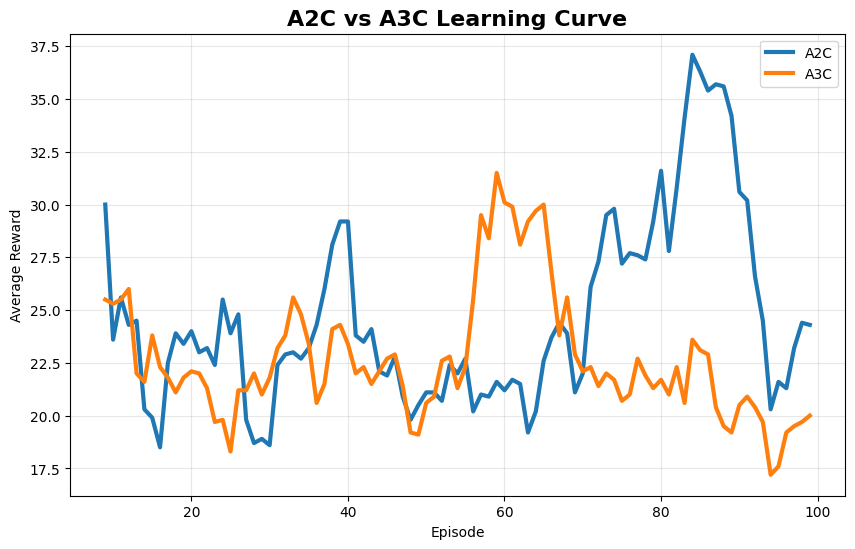

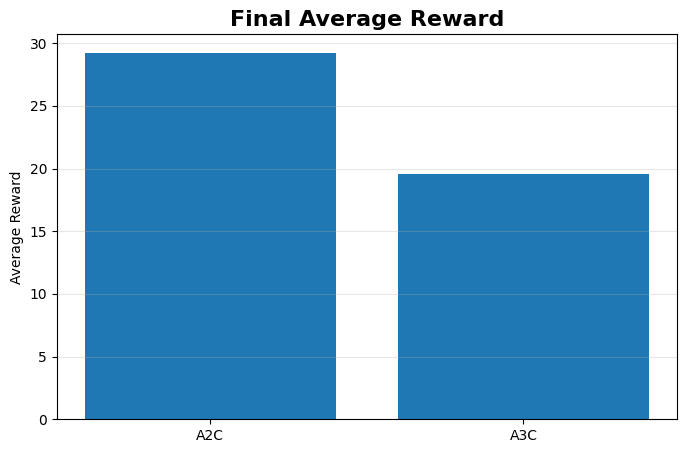

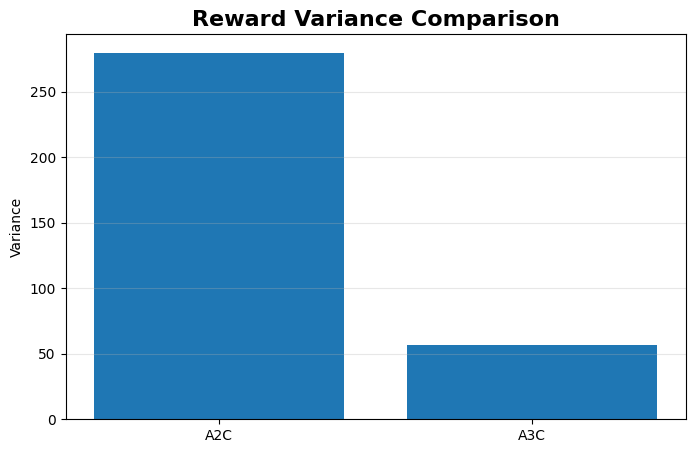

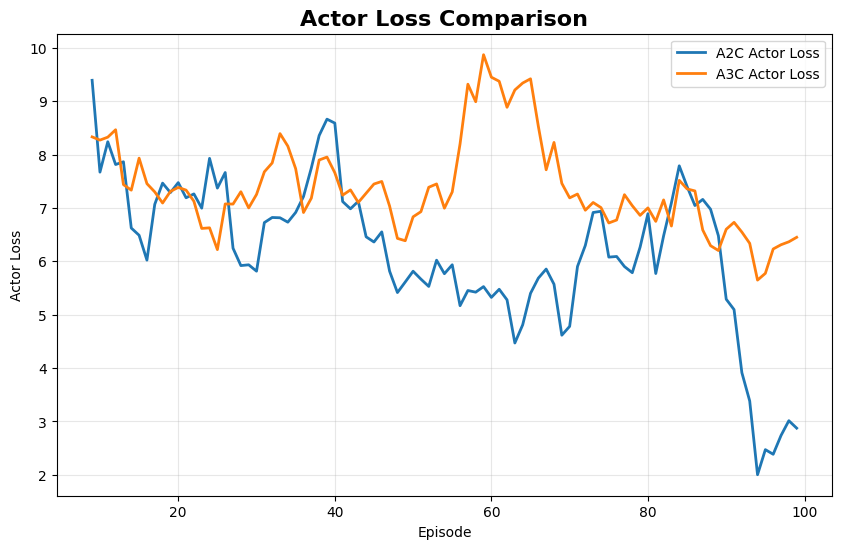

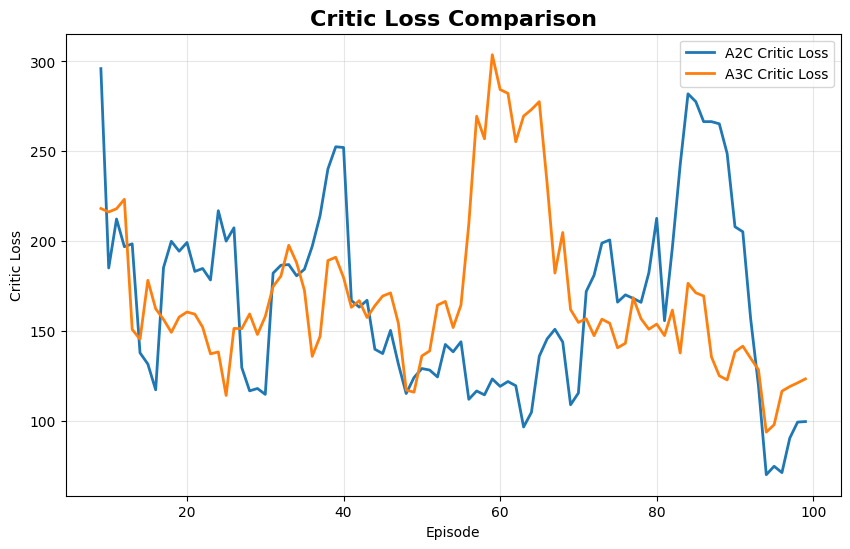

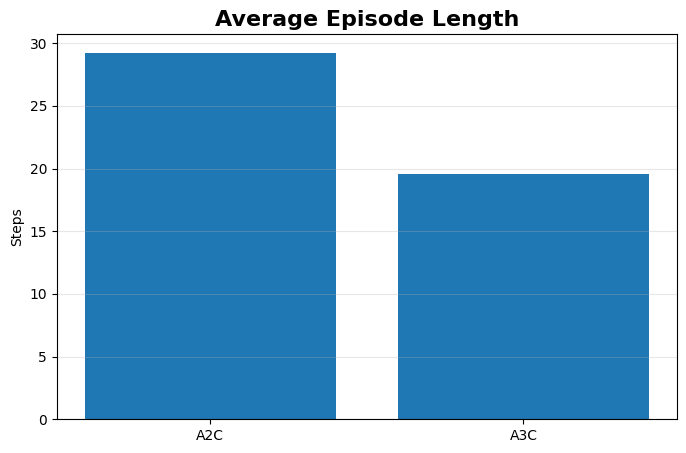

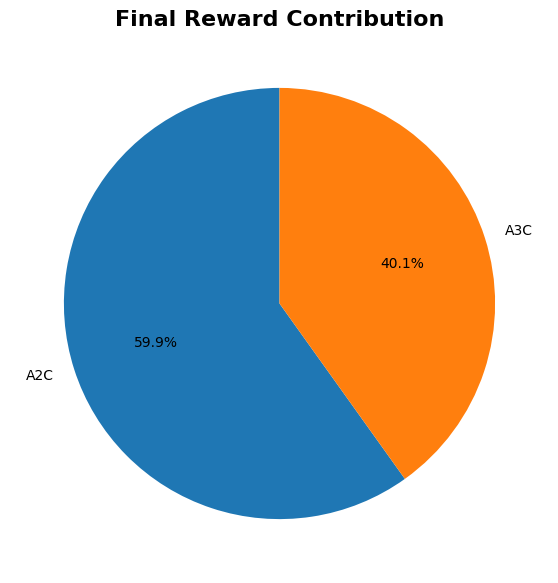



SUMMARY TABLE


,Algorithm,Final Reward,Variance,Average Steps,Training Time
0,A2C,29.25,279.99,29.25,19.65
1,A3C,19.60,56.78,19.60,16.41




FINAL RESULT
Best Final Reward: A2C
More Stable: A3C
Faster Training: A3C


CONCLUSION
A2C and A3C Actor-Critic methods were implemented
using TensorFlow, Keras and Gymnasium.
The actor learned the action policy while the critic
estimated the value of the states.
The algorithms were compared using reward, variance,
actor loss, critic loss, episode length and training time.
The learning curves and comparison charts show the
difference in learning performance between A2C and A3C.

Generated Files:
A2C_A3C_Full_Dataset.csv
A2C_A3C_Summary.csv

Experiment 12 Completed Successfully.


In [1]:
!pip -q install gymnasium tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
import random
import time

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("="*75)
print("EXPERIMENT 12")
print("Actor-Critic Reinforcement Learning using A2C and A3C")
print("="*75)

ENV_NAME="CartPole-v1"
EPISODES=100
GAMMA=0.99
LR=0.001

class ActorCritic(Model):
    def __init__(self):
        super().__init__()
        self.d1=Dense(64,activation="relu")
        self.d2=Dense(64,activation="relu")
        self.actor=Dense(2,activation="softmax")
        self.critic=Dense(1)

    def call(self,x):
        x=self.d1(x)
        x=self.d2(x)
        return self.actor(x),self.critic(x)

def train_a2c():
    env=gym.make(ENV_NAME)
    model=ActorCritic()
    optimizer=Adam(LR)

    rewards=[]
    actor_losses=[]
    critic_losses=[]
    lengths=[]

    start=time.time()

    for episode in range(EPISODES):

        state,_=env.reset()

        states=[]
        actions=[]
        reward_list=[]

        done=False

        while not done:

            states.append(state)

            state_tensor=tf.convert_to_tensor(
                [state],
                dtype=tf.float32
            )

            probs,value=model(
                state_tensor,
                training=False
            )

            action=np.random.choice(
                2,
                p=probs.numpy()[0]
            )

            next_state,reward,terminated,truncated,_=env.step(action)

            done=terminated or truncated

            actions.append(action)
            reward_list.append(reward)

            state=next_state

        returns=[]
        total=0

        for r in reversed(reward_list):
            total=r+GAMMA*total
            returns.insert(0,total)

        states_tensor=tf.convert_to_tensor(
            states,
            dtype=tf.float32
        )

        actions_tensor=tf.convert_to_tensor(
            actions,
            dtype=tf.int32
        )

        returns_tensor=tf.convert_to_tensor(
            returns,
            dtype=tf.float32
        )

        with tf.GradientTape() as tape:

            probs,values=model(
                states_tensor,
                training=True
            )

            values=tf.squeeze(values)

            advantages=returns_tensor-values

            selected_probs=tf.gather(
                probs,
                actions_tensor,
                axis=1,
                batch_dims=1
            )

            log_probs=tf.math.log(
                selected_probs+1e-8
            )

            actor_loss=-tf.reduce_mean(
                log_probs*tf.stop_gradient(advantages)
            )

            critic_loss=tf.reduce_mean(
                tf.square(advantages)
            )

            total_loss=actor_loss+0.5*critic_loss

        gradients=tape.gradient(
            total_loss,
            model.trainable_variables
        )

        optimizer.apply_gradients(
            zip(
                gradients,
                model.trainable_variables
            )
        )

        rewards.append(sum(reward_list))
        actor_losses.append(float(actor_loss.numpy()))
        critic_losses.append(float(critic_loss.numpy()))
        lengths.append(len(reward_list))

    env.close()

    return {
        "rewards":rewards,
        "actor_loss":actor_losses,
        "critic_loss":critic_losses,
        "lengths":lengths,
        "time":time.time()-start
    }

def train_a3c():
    workers=4

    models=[
        ActorCritic()
        for _ in range(workers)
    ]

    optimizers=[
        Adam(LR)
        for _ in range(workers)
    ]

    rewards=[]
    actor_losses=[]
    critic_losses=[]
    lengths=[]

    start=time.time()

    for episode in range(EPISODES):

        worker=episode%workers

        env=gym.make(ENV_NAME)

        model=models[worker]
        optimizer=optimizers[worker]

        state,_=env.reset()

        states=[]
        actions=[]
        reward_list=[]

        done=False

        while not done:

            states.append(state)

            state_tensor=tf.convert_to_tensor(
                [state],
                dtype=tf.float32
            )

            probs,value=model(
                state_tensor,
                training=False
            )

            action=np.random.choice(
                2,
                p=probs.numpy()[0]
            )

            next_state,reward,terminated,truncated,_=env.step(action)

            done=terminated or truncated

            actions.append(action)
            reward_list.append(reward)

            state=next_state

        returns=[]
        total=0

        for r in reversed(reward_list):
            total=r+GAMMA*total
            returns.insert(0,total)

        states_tensor=tf.convert_to_tensor(
            states,
            dtype=tf.float32
        )

        actions_tensor=tf.convert_to_tensor(
            actions,
            dtype=tf.int32
        )

        returns_tensor=tf.convert_to_tensor(
            returns,
            dtype=tf.float32
        )

        with tf.GradientTape() as tape:

            probs,values=model(
                states_tensor,
                training=True
            )

            values=tf.squeeze(values)

            advantages=returns_tensor-values

            selected_probs=tf.gather(
                probs,
                actions_tensor,
                axis=1,
                batch_dims=1
            )

            log_probs=tf.math.log(
                selected_probs+1e-8
            )

            actor_loss=-tf.reduce_mean(
                log_probs*tf.stop_gradient(advantages)
            )

            critic_loss=tf.reduce_mean(
                tf.square(advantages)
            )

            total_loss=actor_loss+0.5*critic_loss

        gradients=tape.gradient(
            total_loss,
            model.trainable_variables
        )

        optimizer.apply_gradients(
            zip(
                gradients,
                model.trainable_variables
            )
        )

        rewards.append(sum(reward_list))
        actor_losses.append(float(actor_loss.numpy()))
        critic_losses.append(float(critic_loss.numpy()))
        lengths.append(len(reward_list))

        env.close()

    return {
        "rewards":rewards,
        "actor_loss":actor_losses,
        "critic_loss":critic_losses,
        "lengths":lengths,
        "time":time.time()-start
    }

print("\nTraining A2C...")
a2c=train_a2c()
print("A2C Completed")

print("\nTraining A3C...")
a3c=train_a3c()
print("A3C Completed")

dataset=pd.DataFrame({
    "Episode":range(1,EPISODES+1),
    "A2C_Reward":a2c["rewards"],
    "A3C_Reward":a3c["rewards"],
    "A2C_Actor_Loss":a2c["actor_loss"],
    "A3C_Actor_Loss":a3c["actor_loss"],
    "A2C_Critic_Loss":a2c["critic_loss"],
    "A3C_Critic_Loss":a3c["critic_loss"],
    "A2C_Episode_Length":a2c["lengths"],
    "A3C_Episode_Length":a3c["lengths"]
})

print("\n")
print("="*75)
print("SAMPLE DATASET")
print("="*75)

display(dataset.head(10))

dataset.to_csv(
    "A2C_A3C_Full_Dataset.csv",
    index=False
)

a2c_smooth=dataset["A2C_Reward"].rolling(10).mean()
a3c_smooth=dataset["A3C_Reward"].rolling(10).mean()

plt.figure(figsize=(10,6))

plt.plot(
    a2c_smooth,
    label="A2C",
    linewidth=3
)

plt.plot(
    a3c_smooth,
    label="A3C",
    linewidth=3
)

plt.title(
    "A2C vs A3C Learning Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

a2c_final=dataset["A2C_Reward"].tail(20).mean()
a3c_final=dataset["A3C_Reward"].tail(20).mean()

plt.figure(figsize=(8,5))

plt.bar(
    ["A2C","A3C"],
    [a2c_final,a3c_final]
)

plt.title(
    "Final Average Reward",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Average Reward")
plt.grid(axis="y",alpha=0.3)
plt.show()

a2c_variance=dataset["A2C_Reward"].tail(20).var()
a3c_variance=dataset["A3C_Reward"].tail(20).var()

plt.figure(figsize=(8,5))

plt.bar(
    ["A2C","A3C"],
    [a2c_variance,a3c_variance]
)

plt.title(
    "Reward Variance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Variance")
plt.grid(axis="y",alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))

plt.plot(
    dataset["A2C_Actor_Loss"].rolling(10).mean(),
    label="A2C Actor Loss",
    linewidth=2
)

plt.plot(
    dataset["A3C_Actor_Loss"].rolling(10).mean(),
    label="A3C Actor Loss",
    linewidth=2
)

plt.title(
    "Actor Loss Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Actor Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))

plt.plot(
    dataset["A2C_Critic_Loss"].rolling(10).mean(),
    label="A2C Critic Loss",
    linewidth=2
)

plt.plot(
    dataset["A3C_Critic_Loss"].rolling(10).mean(),
    label="A3C Critic Loss",
    linewidth=2
)

plt.title(
    "Critic Loss Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Critic Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

a2c_length=dataset["A2C_Episode_Length"].tail(20).mean()
a3c_length=dataset["A3C_Episode_Length"].tail(20).mean()

plt.figure(figsize=(8,5))

plt.bar(
    ["A2C","A3C"],
    [a2c_length,a3c_length]
)

plt.title(
    "Average Episode Length",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Steps")
plt.grid(axis="y",alpha=0.3)
plt.show()

total_reward=a2c_final+a3c_final

plt.figure(figsize=(7,7))

plt.pie(
    [a2c_final,a3c_final],
    labels=["A2C","A3C"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Final Reward Contribution",
    fontsize=16,
    fontweight="bold"
)

plt.show()

comparison=pd.DataFrame({
    "Algorithm":[
        "A2C",
        "A3C"
    ],
    "Final Reward":[
        round(a2c_final,2),
        round(a3c_final,2)
    ],
    "Variance":[
        round(a2c_variance,2),
        round(a3c_variance,2)
    ],
    "Average Steps":[
        round(a2c_length,2),
        round(a3c_length,2)
    ],
    "Training Time":[
        round(a2c["time"],2),
        round(a3c["time"],2)
    ]
})

print("\n")
print("="*75)
print("SUMMARY TABLE")
print("="*75)

display(comparison)

comparison.to_csv(
    "A2C_A3C_Summary.csv",
    index=False
)

best_algorithm=comparison.loc[
    comparison["Final Reward"].idxmax(),
    "Algorithm"
]

stable_algorithm=comparison.loc[
    comparison["Variance"].idxmin(),
    "Algorithm"
]

fast_algorithm=comparison.loc[
    comparison["Training Time"].idxmin(),
    "Algorithm"
]

print("\n")
print("="*75)
print("FINAL RESULT")
print("="*75)

print(
    "Best Final Reward:",
    best_algorithm
)

print(
    "More Stable:",
    stable_algorithm
)

print(
    "Faster Training:",
    fast_algorithm
)

print("\n")
print("="*75)
print("CONCLUSION")
print("="*75)

print(
    "A2C and A3C Actor-Critic methods were implemented"
)

print(
    "using TensorFlow, Keras and Gymnasium."
)

print(
    "The actor learned the action policy while the critic"
)

print(
    "estimated the value of the states."
)

print(
    "The algorithms were compared using reward, variance,"
)

print(
    "actor loss, critic loss, episode length and training time."
)

print(
    "The learning curves and comparison charts show the"
)

print(
    "difference in learning performance between A2C and A3C."
)

print("\nGenerated Files:")
print("A2C_A3C_Full_Dataset.csv")
print("A2C_A3C_Summary.csv")

print("\nExperiment 12 Completed Successfully.")